In [1]:
!pip install finesse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Success

In [2]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

# **Power Recycled Interferometer**

The system is a basic system with only PRM (no FP cavity). The layout is:
```
Laser → PRM → Beamsplitter → ETMX  (X arm, L = 4000 m)
                           → ETMY  (Y arm, L = 4000 m)
                           → Output port (dark fringe)
```

## **Length Sensing**

#### **(a) Simple Michelson**

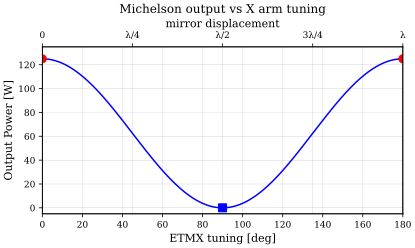

Max output power : 125.0 W  (at bright fringe)
Min output power : 0.0 W  (at dark fringe)


In [33]:
base = finesse.Model()
base.parse("""
    l laser1 P=125
    s s1 laser1.p1 bs1.p1 L=50
    bs bs1 R=0.5 T=0.5
    s armX bs1.p3 ETMX.p1 L=4000
    m ETMX R=1 T=0
    s armY bs1.p2 ETMY.p1 L=4000
    m ETMY R=1 T=0
""")

kat1 = base.deepcopy()
kat1.parse("""
    pd pow_out bs1.p4.o
""")

out = kat1.run(Xaxis("ETMX.phi", "lin", 0, 180, 1000))

fig, ax = plt.subplots()
ax.plot(out.x[0], out['pow_out'], 'b-')
ax.set_xlabel('ETMX tuning [deg]')
ax.set_ylabel('Output Power [W]')
ax.set_title('Michelson output vs X arm tuning')
ax.set_ylim(-5, 135)
ax.grid(True, alpha=0.3)

ax.plot([0, 180], [125, 125], 'ro', markersize=8, label='Bright fringe (constructive)')
ax.plot([90],     [0],        'bs', markersize=8, label='Dark fringe (destructive)')

ax2 = ax.twiny()
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['0', 'λ/4', 'λ/2', '3λ/4', 'λ'])
ax2.set_xlabel('mirror displacement')

plt.tight_layout()
plt.show()

print(f"Max output power : {out['pow_out'].max():.1f} W  (at bright fringe)")
print(f"Min output power : {out['pow_out'].min():.1f} W  (at dark fringe)")

#### **(b) Adding a PRM**

We insert a PRM (R = 0.9, T = 0.1) between the laser and the beamsplitter. The PRM and the Michelson form a resonant cavity that stores light.

We measure 3 outputs:
- `pow_circ` — power stored in the recycling cavity
- `pow_out`  — power at the output
- `pow_refl` — power leaking back toward the laser

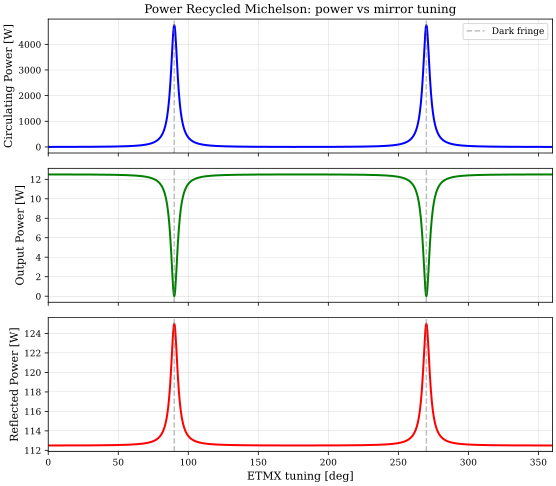

Values at dark fringe:
Circulating power : 4746.7 W
Output power      : 0.0 W
Reflected power   : 125.0 W


In [34]:
prm = finesse.Model()
prm.parse("""
    l laser1 P=125
    s s_in laser1.p1 PRM.p1 L=10
    m PRM R=0.9 T=0.1 phi=0
    s s_prc PRM.p2 bs1.p1 L=40
    bs bs1 R=0.5 T=0.5
    s armX bs1.p3 ETMX.p1 L=4000
    m ETMX R=1 T=0
    s armY bs1.p2 ETMY.p1 L=4000
    m ETMY R=1 T=0

    pd pow_out  bs1.p4.o
    pd pow_refl PRM.p1.o
    pd pow_circ bs1.p1.o
""")


out_prm = prm.run(Xaxis("ETMX.phi", "lin", 0, 360, 1000))


fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axes[0].plot(out_prm.x[0], out_prm['pow_circ'], 'b-', linewidth=2)
axes[0].set_ylabel('Circulating Power [W]')
axes[0].set_title('Power Recycled Michelson: power vs mirror tuning')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(90,  color='gray', linestyle='--', alpha=0.5, label='Dark fringe')
axes[0].axvline(270, color='gray', linestyle='--', alpha=0.5)
axes[0].legend(fontsize=9)

axes[1].plot(out_prm.x[0], out_prm['pow_out'], 'g-', linewidth=2)
axes[1].set_ylabel('Output Power [W]')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(90,  color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(270, color='gray', linestyle='--', alpha=0.5)

axes[2].plot(out_prm.x[0], out_prm['pow_refl'], 'r-', linewidth=2)
axes[2].set_ylabel('Reflected Power [W]')
axes[2].set_xlabel('ETMX tuning [deg]')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(90,  color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(270, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

dark_idx = np.argmin(out_prm['pow_out'])
print(f"Values at dark fringe:")
print(f"Circulating power : {out_prm['pow_circ'][dark_idx]:.1f} W")
print(f"Output power      : {out_prm['pow_out'][dark_idx]:.1f} W")
print(f"Reflected power   : {out_prm['pow_refl'][dark_idx]:.1f} W")

At the dark fringe ( 90° and 270°), the circulating power reaches nearly 4750 W, larger than the 125 W input laser power. This shows the effect of the Power Recycling Mirror, which causes light to build up inside the recycling cavity.

At the same points, the output power drops close to zero because the two arm fields interfere destructively at the output port.

Another observation is that reflected power $≈ 125 W$ at the dark fringe, instead of dropping to 0. We use a simple model with equal arms and perfectly reflective mirrors. As a result, light is still reflected towards the laser.


#### **(c) length sensing**

We zoom in the output power plots to understand the sensing behaviour near the dark fringe region!

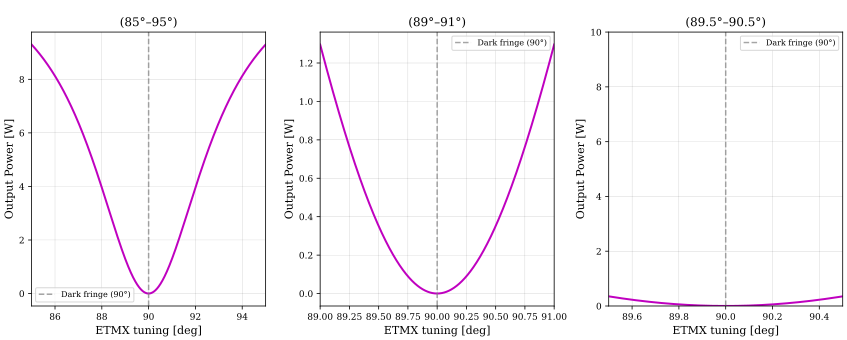

In [40]:
out_zoom1 = prm.run(Xaxis("ETMX.phi", "lin", 85,   95,   1000))
out_zoom2 = prm.run(Xaxis("ETMX.phi", "lin", 89,   91,   1000))
out_zoom3 = prm.run(Xaxis("ETMX.phi", "lin", 89.5, 90.5, 1000))

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

zooms = [
    (out_zoom1, '85°–95°'),
    (out_zoom2, '89°–91°'),
    (out_zoom3, '89.5°–90.5°'),
]

for ax, (data, xrange) in zip(axes, zooms):
    ax.plot(data.x[0], data['pow_out'], 'm-', linewidth=2)
    ax.axvline(90, color='gray', linestyle='--', alpha=0.7, label='Dark fringe (90°)')
    ax.set_xlabel('ETMX tuning [deg]')
    ax.set_ylabel('Output Power [W]')
    ax.set_title(f'\n({xrange})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
ax.set_ylim(0,10)
plt.tight_layout()
plt.show()

The curve near the dark fringe is parabolic as,
$$P ∝(\Delta\phi)^2$$

The closer we zoom to 90°, the curve becomes flatter. We cannot differentiate whether the mirror moved left or right. We can technically say that the slope is 0 ($ \frac{dP}{d ϕ} = 0$)

#### Confirming that the slope $ \frac{dP}{d ϕ} = 0$ from the 89.5° - 90.5° plot




In [49]:
phi  = out_zoom3.x[0]
P    = out_zoom3['pow_out']

#dP/dphi
dP_dphi = np.gradient(P, phi)

index = np.argmin(np.abs(phi - 90.0))

print(f"dP/dφ at dark fringe: {dP_dphi[index]:.3f} W/deg")

dP/dφ at dark fringe: 0.000 W/deg


The derivative $ \frac{dP}{d ϕ} = 0$  at 90°.

The direct power sensing gives no directional information exactly at the operating point as the curve is symmetric. It tells us how far the mirror moved but not which direction.

Thus, we can use PDH sensing by using sidebands to generate error signal at the dark fringe.

## **(II): Understanding Power Recycling**

#### **Step 1: Power Recycling Gain**

Power Recycling Gain = the factor by which the circulating power exceeds the input laser power.

In [51]:
reflectivities = [0.5,0.6, 0.8, 0.9, 0.99]
R_IFO = 1.0  # lossless arms

print("Power Recycling Gain: theory vs simulation\n")
print(f"{'R_PRM':<8} {'G_sim':>8} {'G_theory':>10}")
print("-" * 30)

for R_PRM in reflectivities:
    T_PRM = 1 - R_PRM

    test_model = finesse.Model()
    test_model.parse(f"""
        l laser1 P=125
        s s_in laser1.p1 PRM.p1 L=10
        m PRM R={R_PRM} T={T_PRM} phi=0
        s s_prc PRM.p2 bs1.p1 L=40
        bs bs1 R=0.5 T=0.5
        s armX bs1.p3 ETMX.p1 L=4000
        m ETMX R=1 T=0
        s armY bs1.p2 ETMY.p1 L=4000
        m ETMY R=1 T=0
        pd pow_circ bs1.p1.o
    """)

    out_test = test_model.run(Xaxis("ETMX.phi", "lin", 0, 360, 1000))
    G_sim    = out_test['pow_circ'].max() / 125
    G_theory = T_PRM / (1 - (R_PRM * R_IFO)**0.5)**2

    print(f"{R_PRM:<8.2f} {G_sim:>8.1f} {G_theory:>10.1f}")

Power Recycling Gain: theory vs simulation

R_PRM       G_sim   G_theory
------------------------------
0.50          5.8        5.8
0.60          7.9        7.9
0.80         17.9       17.9
0.90         38.0       38.0
0.99        398.0      398.0


As the PRM reflectivity increases, the circulating power inside the recycling cavity also increases.

At the same time, the resonance becomes much sharper for high reflectivities. This means the interferometer becomes more sensitive to small tuning changes.

#### **Step 2: Effect of PRM on circulating power**

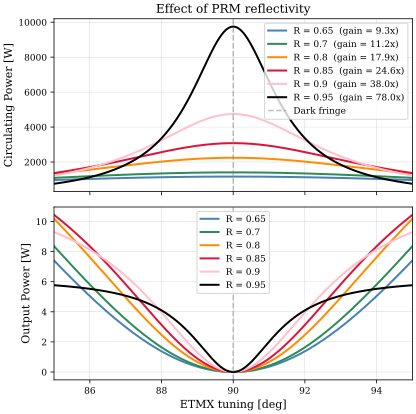

In [57]:
reflectivities = [0.65, 0.7, 0.8, 0.85, 0.9, 0.95]
colors = ['steelblue', 'seagreen', 'darkorange', 'crimson', 'pink', 'black']

fig, (ax_circ, ax_out) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

gains = []

for R, color in zip(reflectivities, colors):
    T = 1 - R

    model = finesse.Model()
    model.parse(f"""
        l laser1 P=125
        s s_in laser1.p1 PRM.p1 L=10
        m PRM R={R} T={T} phi=0
        s s_prc PRM.p2 bs1.p1 L=40
        bs bs1 R=0.5 T=0.5
        s armX bs1.p3 ETMX.p1 L=4000
        m ETMX R=1 T=0
        s armY bs1.p2 ETMY.p1 L=4000
        m ETMY R=1 T=0
        pd pow_out  bs1.p4.o
        pd pow_refl PRM.p1.o
        pd pow_circ bs1.p1.o
    """)

    out = model.run(Xaxis("ETMX.phi", "lin", 85, 95, 1000))

    G = out['pow_circ'].max() / 125.0
    gains.append(G)

    ax_circ.plot(out.x[0], out['pow_circ'], color=color,
                 linewidth=2, label=f'R = {R}  (gain = {G:.1f}x)')
    ax_out.plot(out.x[0], out['pow_out'],  color=color,
                linewidth=2, label=f'R = {R}')

ax_circ.set_ylabel('Circulating Power [W]')
ax_circ.set_title('Effect of PRM reflectivity')
ax_circ.axvline(90, color='gray', linestyle='--', alpha=0.5, label='Dark fringe')
ax_circ.legend(fontsize=9)
ax_circ.grid(True, alpha=0.3)

ax_out.set_ylabel('Output Power [W]')
ax_out.set_xlabel('ETMX tuning [deg]')
ax_out.axvline(90, color='gray', linestyle='--', alpha=0.5)
ax_out.legend(fontsize=9)
ax_out.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Higher PRM reflectivity → more light is recycled → higher circulating power

- But higher R also makes the recycling cavity resonance sharper.The interferometer becomes more sensitive to small tuning changes.

 - Higher reflectivity improves the circulating power, but it also makes the interferometer more difficult to control.